In [1]:
import os
os.chdir(r"C:\Users\mpree\cfpb-classifier")
print(os.getcwd())

C:\Users\mpree\cfpb-classifier


In [3]:
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score,f1_score,classification_report
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

C:\Users\mpree\anaconda3\envs\demo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
with open('saved_models/preprocessed_data.pkl','rb') as f:
    data=pickle.load(f)
X_train=data['X_train']
X_val=data['X_val']
X_test=data['X_test']
y_train=data['y_train']
y_test=data['y_test']
y_val=data['y_val']
num_classes=data['num_classes']
le=data['le']

print("Data loaded!")
print(f"Train : {len(X_train)} | Val:{len(X_val)} | Test:{len(X_test)}")


Data loaded!
Train : 36000 | Val:4000 | Test:10000


In [11]:
VOCAB_SIZE=20000
MAX_LEN=256
EMBED_DIM=100

tokenizer=Tokenizer(num_words=VOCAB_SIZE,oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
X_train_enc=pad_sequences(tokenizer.texts_to_sequences(X_train),maxlen=MAX_LEN,padding='post',truncating='post')
X_val_enc=pad_sequences(tokenizer.texts_to_sequences(X_val),maxlen=MAX_LEN,padding='post',truncating='post')
X_test_enc=pad_sequences(tokenizer.texts_to_sequences(X_test),maxlen=MAX_LEN,padding='post',truncating='post')

print(f"X_train shape:{X_train_enc.shape}")
print(f"X_val shape:{X_val_enc.shape}")
print(f"X_test shape:{X_test_enc.shape}")

X_train shape:(36000, 256)
X_val shape:(4000, 256)
X_test shape:(10000, 256)


In [17]:
embeddings_index={}
with open('glove.6B.100d.txt',encoding='utf-8') as f:
    for line in f:
        values=line.split()
        word=values[0]
        vector=np.asarray(values[1:],dtype='float32')
        embeddings_index[word]=vector
print(f"GloVe loaded : {len(embeddings_index)} vectors")

embedding_matrix=np.zeros((VOCAB_SIZE,EMBED_DIM))
for word,i in tokenizer.word_index.items():
    if i< VOCAB_SIZE:
        vector=embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[i]=vector
print(f"Embedding matrix: {embedding_matrix.shape}")

GloVe loaded : 400000 vectors
Embedding matrix: (20000, 100)


In [23]:
def build_bilstm(units=128,dropout=0.4,max_len=MAX_LEN,trainable=False):
    model=models.Sequential([
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBED_DIM,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=trainable
        ),
        layers.Bidirectional(layers.LSTM(units,return_sequences=True)),
        layers.Bidirectional(layers.LSTM(units//2)),
        layers.Dropout(dropout),
        layers.Dense(num_classes,activation='softmax')
    ])
    return model
bilstm_model=build_bilstm()
bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [25]:
early_stop=tf.keras.callbacks.EarlyStopping(
    patience=2,restore_best_weights=True)
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Phase 1 - Training with frozen embeddings...")
history1=bilstm_model.fit(
    X_train_enc,y_train,validation_data=(X_val_enc,y_val),
    epochs=5,batch_size=64,callbacks=[early_stop]
)

Phase 1 - Training with frozen embeddings...
Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 413s 725ms/step - accuracy: 0.7252 - loss: 0.7657 - val_accuracy: 0.7985 - val_loss: 0.5697
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 427s 759ms/step - accuracy: 0.8051 - loss: 0.5685 - val_accuracy: 0.8040 - val_loss: 0.5578
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 443s 786ms/step - accuracy: 0.8260 - loss: 0.5128 - val_accuracy: 0.8315 - val_loss: 0.4862
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 442s 784ms/step - accuracy: 0.8404 - loss: 0.4675 - val_accuracy: 0.8378 - val_loss: 0.4786
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 441s 784ms/step - accuracy: 0.8522 - loss: 0.4338 - val_accuracy: 0.8420 - val_loss: 0.4568


In [27]:
preds_default=np.argmax(bilstm_model.predict(X_test_enc),axis=1)
acc_default=accuracy_score(y_test,preds_default)
f1_default=f1_score(y_test,preds_default,average='macro')

print("BiLSTM DEFAULT RESULTS")
print(f"Accuracy :{acc_default:.4f}")
print(f"F1-Score :{f1_default:.4f}")
print(classification_report(y_test,preds_default,target_names=le.classes_))

313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step
BiLSTM DEFAULT RESULTS
Accuracy :0.8541
F1-Score :0.8536
                     precision    recall  f1-score   support

        credit_card       0.84      0.81      0.82      2000
   credit_reporting       0.87      0.82      0.84      2000
    debt_collection       0.86      0.83      0.85      2000
mortgages_and_loans       0.86      0.89      0.88      2000
     retail_banking       0.85      0.92      0.88      2000

           accuracy                           0.85     10000
          macro avg       0.85      0.85      0.85     10000
       weighted avg       0.85      0.85      0.85     10000



In [33]:
print("Phase 2-Fine tuning embeddings..")
bilstm_model.layers[0].trainable=True

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history2=bilstm_model.fit(
    X_train_enc,y_train,validation_data=(X_val_enc,y_val),
    epochs=5,batch_size=64,callbacks=[early_stop])


Phase 2-Fine tuning embeddings..
Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 480s 835ms/step - accuracy: 0.8781 - loss: 0.3637 - val_accuracy: 0.8455 - val_loss: 0.4397
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 440s 782ms/step - accuracy: 0.8867 - loss: 0.3398 - val_accuracy: 0.8528 - val_loss: 0.4291
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 441s 783ms/step - accuracy: 0.8919 - loss: 0.3223 - val_accuracy: 0.8522 - val_loss: 0.4338
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 365s 648ms/step - accuracy: 0.8987 - loss: 0.3050 - val_accuracy: 0.8518 - val_loss: 0.4373


In [35]:
preds_ft=np.argmax(bilstm_model.predict(X_test_enc),axis=1)
acc_ft=accuracy_score(y_test,preds_ft)
f1_ft=f1_score(y_test,preds_ft,average='macro')
print("BiLSTM FINE TUNED RESULTS")
print(f"Accuracy : {acc_ft:.4f}")
print(f"F1 SCORE  :{f1_ft:.4f}")
print(classification_report(y_test,preds_ft,target_names=le.classes_))

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step
BiLSTM FINE TUNED RESULTS
Accuracy : 0.8608
F1 SCORE  :0.8607
                     precision    recall  f1-score   support

        credit_card       0.83      0.84      0.84      2000
   credit_reporting       0.86      0.84      0.85      2000
    debt_collection       0.87      0.83      0.85      2000
mortgages_and_loans       0.85      0.90      0.88      2000
     retail_banking       0.88      0.89      0.88      2000

           accuracy                           0.86     10000
          macro avg       0.86      0.86      0.86     10000
       weighted avg       0.86      0.86      0.86     10000



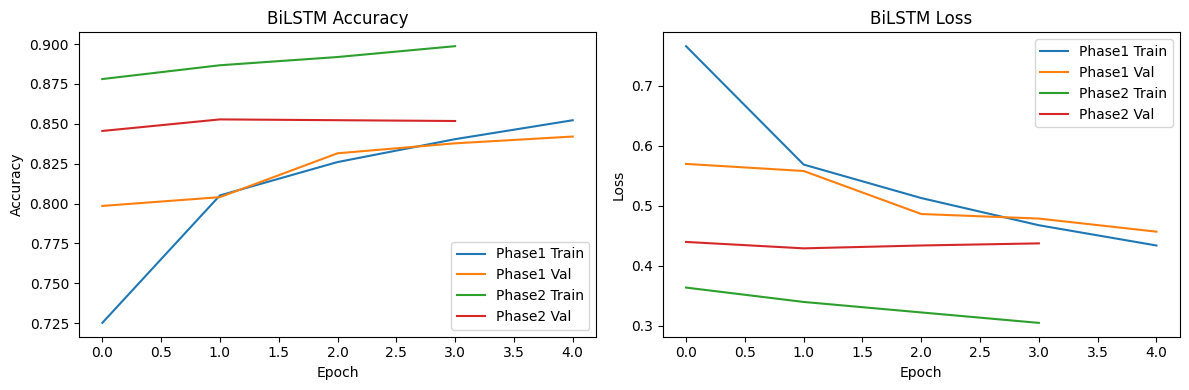

In [37]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'],     label='Phase1 Train')
plt.plot(history1.history['val_accuracy'], label='Phase1 Val')
plt.plot(history2.history['accuracy'],     label='Phase2 Train')
plt.plot(history2.history['val_accuracy'], label='Phase2 Val')
plt.title('BiLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'],     label='Phase1 Train')
plt.plot(history1.history['val_loss'], label='Phase1 Val')
plt.plot(history2.history['loss'],     label='Phase2 Train')
plt.plot(history2.history['val_loss'], label='Phase2 Val')
plt.title('BiLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [39]:

print(f"{'Model':<25} {'Accuracy':>10} {'F1':>10}")
print(f"{'Logistic Regression':<25} {0.8616:>10.4f} {0.8615:>10.4f}")
print(f"{'RNN (tuned)':<25} {0.7668:>10.4f} {0.7656:>10.4f}")
print(f"{'BiLSTM Default':<25} {acc_default:>10.4f} {f1_default:>10.4f}")
print(f"{'BiLSTM Fine Tuned':<25} {acc_ft:>10.4f} {f1_ft:>10.4f}")

Model                       Accuracy         F1
Logistic Regression           0.8616     0.8615
RNN (tuned)                   0.7668     0.7656
BiLSTM Default                0.8541     0.8536
BiLSTM Fine Tuned             0.8608     0.8607


In [41]:
bilstm_model.save('saved_models/bilstm_model.h5')
with open('saved_models/results.pkl', 'rb') as f:
    results=pickle.load(f)
results['lstm_acc']=acc_ft
results['lstm_f1']=f1_ft
with open('saved_models/results.pkl','wb') as f:
    pickle.dump(results,f)
print("BiLSTM saved")
print(f"Accuracy : {acc_ft:.4f}")
print(f"F1       : {f1_ft:.4f}")



BiLSTM saved
Accuracy : 0.8608
F1       : 0.8607
